# Querying Iceberg Tables with Apache DataFusion

**Architecture:**
```
Jupyter
    |
DataFusion Python API
    |
DataFusion
    |
Iceberg Table Provider
    |
Iceberg Catalog
    |
Iceberg Data Files
    |
Arrow
    |
Pandas
```

DataFusion registers the Iceberg table as a native table provider via `register_table_provider()`.
Queries are pushed down to Iceberg — DataFusion reads Parquet data files directly through Arrow, with zero-copy conversion to Pandas.

## Prerequisites
Run the Airflow DAG `Insert_Customer_Order_Data_To_Iceberg` first to populate sample data.

## 1. Connect to Iceberg REST Catalog

Reference: [DataFusion Data Sources — Iceberg](https://datafusion.apache.org/python/user-guide/data-sources.html)

In [10]:
import time
from pyiceberg.catalog import load_catalog

timings = {}
_start = time.time()

# Connect to the Iceberg REST catalog
catalog = load_catalog(
    "rest",
    **{
        "uri": "http://iceberg-rest:8181",
        "s3.endpoint": "http://minio:9000",
        "s3.access-key-id": "minioadmin",
        "s3.secret-access-key": "minioadmin",
        "s3.region": "us-east-1",
    }
)

# List available namespaces and tables
namespaces = catalog.list_namespaces()
print(f"Namespaces: {namespaces}")
for ns in namespaces:
    tables = catalog.list_tables(ns[0])
    print(f"Tables in {ns[0]}: {tables}")

timings["1. Connect to Iceberg catalog"] = time.time() - _start
print(f"Done in {timings['1. Connect to Iceberg catalog']:.3f}s")

Namespaces: [('ecommerce',)]
Tables in ecommerce: [('ecommerce', 'raw_orders')]
Done in 0.050s


## 2. Register Iceberg Table with DataFusion

Reference: [DataFusion Data Sources — Iceberg](https://datafusion.apache.org/python/user-guide/data-sources.html)

The official pattern is:
```python
ctx = SessionContext()
ctx.register_table("table_name", iceberg_table)
```
However, the REST catalog injects an `AuthManager` object into `io.properties` that the Rust bindings cannot serialize ([apache/iceberg-python#2544](https://github.com/apache/iceberg-python/issues/2544)). We work around this by constructing the `IcebergDataFusionTable` manually with string-only properties.

In [11]:
from datafusion import SessionContext
from pyiceberg_core.datafusion import IcebergDataFusionTable

_start = time.time()

# Load Iceberg table — same as official docs:
#   https://datafusion.apache.org/python/user-guide/data-sources.html
iceberg_table = catalog.load_table("ecommerce.raw_orders")

# Official pattern (works with in-memory catalog):
#   ctx.register_table("raw_orders", iceberg_table)
#
# Workaround for REST catalog: filter out non-string AuthManager objects
# from io.properties before passing to Rust bindings.
# See: https://github.com/apache/iceberg-python/issues/2544
file_io_props = {k: v for k, v in iceberg_table.io.properties.items() if isinstance(v, str)}

ctx = SessionContext()
provider = IcebergDataFusionTable(
    identifier=iceberg_table.name(),
    metadata_location=iceberg_table.metadata_location,
    file_io_properties=file_io_props,
)
ctx.register_table("raw_orders", provider)

print(f"Registered 'raw_orders' as DataFusion table provider")

timings["2. Register Iceberg table provider"] = time.time() - _start
print(f"Done in {timings['2. Register Iceberg table provider']:.3f}s")

Registered 'raw_orders' as DataFusion table provider
Done in 0.066s


## 3. Query Iceberg Table -> Pandas DataFrame

In [12]:
_start = time.time()

# Query with DataFusion SQL — reads Iceberg data files natively via table provider
df = ctx.sql("""
    SELECT *
    FROM raw_orders
    ORDER BY order_date DESC
    LIMIT 10
""").to_pandas()

timings["3. Query raw_orders (top 10)"] = time.time() - _start
print(f"Done in {timings['3. Query raw_orders (top 10)']:.3f}s")
df

Done in 0.184s


,order_id,customer_id,product_name,quantity,price,order_date,status
0,ORD-00821,CUST-0036,Mouse Pad,5,12.99,2024-12-28,pending
1,ORD-417622,CUST-0033,Wireless Mouse,1,29.99,2024-12-28,pending
2,ORD-00005,CUST-0045,Wireless Mouse,2,29.99,2024-12-28,cancelled
3,ORD-417551,CUST-0034,Webcam HD,3,59.99,2024-12-28,completed
4,ORD-00578,CUST-0003,Monitor Stand,2,34.99,2024-12-28,completed
5,ORD-417644,CUST-0025,Mouse Pad,1,12.99,2024-12-28,completed
6,ORD-00481,CUST-0038,Desk Lamp,3,24.99,2024-12-28,completed
7,ORD-416977,CUST-0027,Mechanical Keyboard,4,89.99,2024-12-28,pending
8,ORD-01276,CUST-0029,Wireless Mouse,2,29.99,2024-12-28,completed
9,ORD-00453,CUST-0039,Mouse Pad,3,12.99,2024-12-28,completed


## 4. Aggregation — Revenue by Product

In [13]:
_start = time.time()

revenue_by_product = ctx.sql("""
    SELECT
        product_name,
        COUNT(*) AS total_orders,
        SUM(quantity) AS total_units,
        SUM(CAST(price AS DOUBLE) * CAST(quantity AS DOUBLE)) AS total_revenue,
        ROUND(AVG(CAST(price AS DOUBLE)), 2) AS avg_price
    FROM raw_orders
    WHERE status = 'completed'
    GROUP BY product_name
    ORDER BY total_revenue DESC
""").to_pandas()

timings["4. Revenue by product"] = time.time() - _start
print(f"Done in {timings['4. Revenue by product']:.3f}s")
revenue_by_product

Done in 0.115s


,product_name,total_orders,total_units,total_revenue,avg_price
0,Mechanical Keyboard,60081,180270,1.622250e+07,89.99
1,Headphones,60525,181628,1.452842e+07,79.99
2,Webcam HD,60129,180991,1.085765e+07,59.99
3,USB-C Hub,59929,179940,8.187270e+06,45.50
4,Monitor Stand,60340,181245,6.341763e+06,34.99
5,Wireless Mouse,59866,179326,5.377987e+06,29.99
6,Desk Lamp,59923,179594,4.488054e+06,24.99
7,Laptop Sleeve,59622,179436,3.586926e+06,19.99
8,Mouse Pad,60027,180061,2.338992e+06,12.99
9,Cable Organizer,60300,180921,1.807401e+06,9.99


## 5. Time-Series — Orders by Month

In [14]:
_start = time.time()

orders_by_month = ctx.sql("""
    SELECT
        DATE_TRUNC('month', order_date) AS month,
        COUNT(*) AS order_count,
        SUM(CAST(price AS DOUBLE) * CAST(quantity AS DOUBLE)) AS revenue
    FROM raw_orders
    WHERE status != 'cancelled'
    GROUP BY DATE_TRUNC('month', order_date)
    ORDER BY month
""").to_pandas()

timings["5. Orders by month"] = time.time() - _start
print(f"Done in {timings['5. Orders by month']:.3f}s")
orders_by_month

Done in 0.107s


,month,order_count,revenue
0,2024-01-01,66257,8133345.38
1,2024-02-01,66705,8163322.04
2,2024-03-01,66217,8119789.54
3,2024-04-01,66914,8218459.60
4,2024-05-01,67015,8240824.92
5,2024-06-01,66861,8230805.64
6,2024-07-01,66825,8211074.82
7,2024-08-01,66688,8153145.47
8,2024-09-01,67115,8276379.83
9,2024-10-01,66491,8134838.21


## 6. Visualization — Revenue by Month

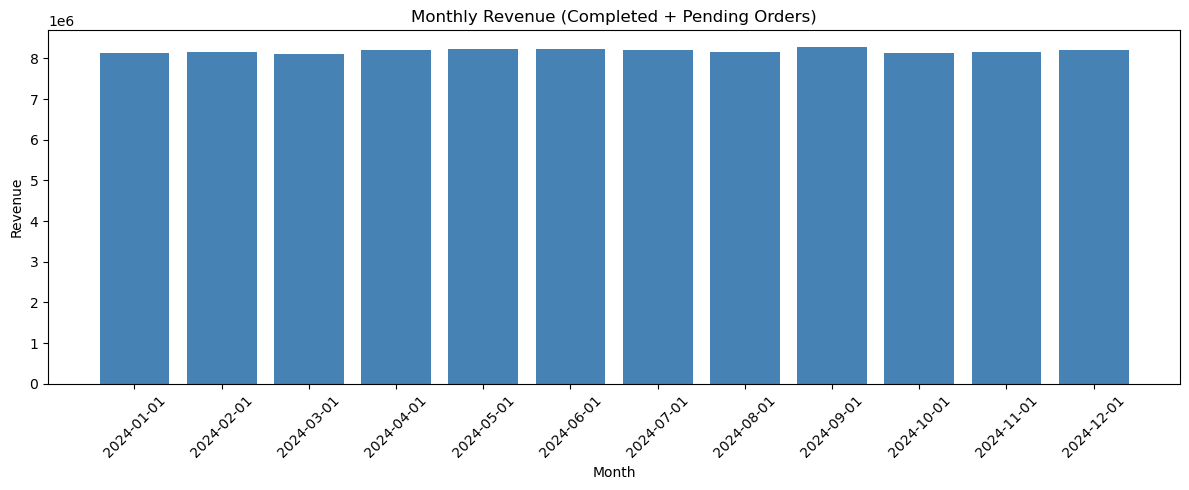

Done in 0.112s


In [15]:
import matplotlib.pyplot as plt

_start = time.time()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(orders_by_month["month"].astype(str), orders_by_month["revenue"], color="steelblue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.set_title("Monthly Revenue (Completed + Pending Orders)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

timings["6. Visualization"] = time.time() - _start
print(f"Done in {timings['6. Visualization']:.3f}s")

## 7. Customer Analysis — Top Customers

In [16]:
_start = time.time()

top_customers = ctx.sql("""
    SELECT
        customer_id,
        COUNT(*) AS order_count,
        SUM(CAST(price AS DOUBLE) * CAST(quantity AS DOUBLE)) AS total_spent,
        MIN(order_date) AS first_order,
        MAX(order_date) AS last_order
    FROM raw_orders
    WHERE status = 'completed'
    GROUP BY customer_id
    ORDER BY total_spent DESC
    LIMIT 10
""").to_pandas()

timings["7. Top customers"] = time.time() - _start
print(f"Done in {timings['7. Top customers']:.3f}s")
top_customers

Done in 0.148s


,customer_id,order_count,total_spent,first_order,last_order
0,CUST-0013,12125,1505618.57,2024-01-01,2024-12-28
1,CUST-0048,12149,1501616.20,2024-01-01,2024-12-28
2,CUST-0044,12104,1497770.10,2024-01-01,2024-12-28
3,CUST-0017,12185,1495640.09,2024-01-01,2024-12-28
4,CUST-0034,12016,1495615.06,2024-01-01,2024-12-28
5,CUST-0050,12143,1494907.76,2024-01-01,2024-12-28
6,CUST-0039,12080,1494796.80,2024-01-01,2024-12-28
7,CUST-0002,12135,1494604.11,2024-01-01,2024-12-28
8,CUST-0022,12157,1493471.41,2024-01-01,2024-12-28
9,CUST-0016,12072,1492024.19,2024-01-01,2024-12-28


## 8. Filtered Query — Completed Orders from June 2024

In [17]:
_start = time.time()

df_filtered = ctx.sql("""
    SELECT
        order_id,
        customer_id,
        product_name,
        price,
        quantity,
        order_date
    FROM raw_orders
    WHERE status = 'completed'
      AND order_date >= DATE '2024-06-01'
    ORDER BY order_date
""").to_pandas()

timings["8. Filtered query (June 2024+)"] = time.time() - _start
print(f"Filtered rows: {len(df_filtered)}")
print(f"Done in {timings['8. Filtered query (June 2024+)']:.3f}s")
df_filtered.head(10)

Filtered rows: 350889
Done in 0.491s


,order_id,customer_id,product_name,price,quantity,order_date
0,ORD-671386,CUST-0002,Laptop Sleeve,19.99,5,2024-06-01
1,ORD-519898,CUST-0038,USB-C Hub,45.50,5,2024-06-01
2,ORD-724730,CUST-0014,Headphones,79.99,5,2024-06-01
3,ORD-557375,CUST-0024,Mechanical Keyboard,89.99,1,2024-06-01
4,ORD-250838,CUST-0034,Mechanical Keyboard,89.99,5,2024-06-01
5,ORD-333790,CUST-0021,Cable Organizer,9.99,1,2024-06-01
6,ORD-714266,CUST-0023,Headphones,79.99,5,2024-06-01
7,ORD-545348,CUST-0010,USB-C Hub,45.50,3,2024-06-01
8,ORD-333870,CUST-0034,Laptop Sleeve,19.99,4,2024-06-01
9,ORD-585057,CUST-0045,Cable Organizer,9.99,4,2024-06-01


## Summary

```
Jupyter  →  DataFusion Python API  →  DataFusion  →  Iceberg Table Provider  →  Iceberg Data Files  →  Arrow  →  Pandas
```

| Pain Point | Old Way (Spark) | New Way (DataFusion + Iceberg Table Provider) |
|---|---|---|
| Slow queries | SparkSQL over cluster | DataFusion in-process, native Iceberg reads |
| Manual data loading | PyIceberg scan → Arrow → register batches | `register_table_provider()` — DataFusion reads Iceberg directly |
| Transformation | PySpark → toPandas() conversion | `.to_pandas()` from Arrow — zero copy |
| Dependencies | PySpark + PyIceberg + PyArrow | `datafusion` + `pyiceberg[datafusion]` |

## 9. Performance Summary

In [18]:
import pandas as pd

summary = pd.DataFrame([
    {"Step": k, "Time (s)": f"{v:.3f}"}
    for k, v in timings.items()
])
total = sum(timings.values())
summary.loc[len(summary)] = {"Step": "TOTAL", "Time (s)": f"{total:.3f}"}
summary

,Step,Time (s)
0,1. Connect to Iceberg catalog,0.050
1,2. Register Iceberg table provider,0.066
2,3. Query raw_orders (top 10),0.184
3,4. Revenue by product,0.115
4,5. Orders by month,0.107
5,6. Visualization,0.112
6,7. Top customers,0.148
7,8. Filtered query (June 2024+),0.491
8,TOTAL,1.273
